# Synthetic Glucose + HbA1c Dataset (clean build)

This notebook generates a condition-aware glucose time series suitable for forecasting glucose (g_mean) and HbA1c. It integrates:
- Exercise as minutes/day
- Insulin adherence from prescribed regimen (doses_taken/prescribed)
- Chronic conditions and episodic events affecting glucose
- Clear build pipeline and QA checks



In [1]:
# Imports & Config
import numpy as np
import pandas as pd
from dataclasses import dataclass

pd.options.display.float_format = lambda x: f"{x:.3f}"

@dataclass
class CohortConfig:
    n_patients: int = 50
    n_days: int = 180
    seed: int = 42

@dataclass
class PrevalenceConfig:
    has_CVD: float = 0.20
    has_CKD: float = 0.12
    has_chronic_allergy: float = 0.25
    alcohol_user: float = 0.35
    smoker: float = 0.25

@dataclass
class EventRates:
    alcohol_user_low: float = 0.05
    alcohol_user_high: float = 0.10
    alcohol_non_user: float = 0.01
    smoker_low: float = 0.10
    smoker_high: float = 0.15
    smoker_non_user: float = 0.02
    allergy_baseline: float = 0.05
    allergy_with_condition_low: float = 0.08
    allergy_with_condition_high: float = 0.12
    alcohol_rebound_prob: float = 0.20

@dataclass
class EffectsConfig:
    CVD_mean: float = 10
    CVD_std: float = 5
    CKD_mean_low: float = 5
    CKD_mean_high: float = 15
    CKD_std_low: float = 8
    CKD_std_high: float = 12
    ALLERGY_CHRONIC_mean: float = 5
    ALLERGY_CHRONIC_std: float = 3
    ALCOHOL_USER_mean: float = -5
    ALCOHOL_USER_std: float = 5
    SMOKER_mean: float = 10
    SMOKER_std: float = 3

    ALLERGY_FLARE_mean_low: float = 15
    ALLERGY_FLARE_mean_high: float = 25
    ALLERGY_FLARE_std_low: float = 3
    ALLERGY_FLARE_std_high: float = 6

    ILLNESS_mean_low: float = 20
    ILLNESS_mean_high: float = 40
    ILLNESS_std_low: float = 5
    ILLNESS_std_high: float = 10

    STRESS_HIGH_mean_low: float = 10
    STRESS_HIGH_mean_high: float = 20
    STRESS_HIGH_std_low: float = 3
    STRESS_HIGH_std_high: float = 6

    ALCOHOL_DAY_mean_low: float = 20
    ALCOHOL_DAY_mean_high: float = 40
    ALCOHOL_DAY_std: float = 10

    SMOKING_DAY_mean: float = 20
    SMOKING_DAY_std_low: float = 3
    SMOKING_DAY_std_high: float = 5

    REBOUND_mean_low: float = 15
    REBOUND_mean_high: float = 30
    REBOUND_std: float = 5

    INTERACT_ALCOHOL_INSULIN_mean_low: float = 30
    INTERACT_ALCOHOL_INSULIN_mean_high: float = 60
    INTERACT_ALCOHOL_INSULIN_std: float = 15

    INTERACT_ALLERGY_ILLNESS_mean_low: float = 40
    INTERACT_ALLERGY_ILLNESS_mean_high: float = 60
    INTERACT_ALLERGY_ILLNESS_std: float = 15

    insulin_dose_threshold: float = 10

COHORT = CohortConfig()
PREV = PrevalenceConfig()
RATES = EventRates()
EFFECTS = EffectsConfig()

rng = np.random.default_rng(COHORT.seed)


In [2]:
# 1) Base simulator with integrated exercise minutes and regimen adherence

def generate_base_panel(n_patients:int, n_days:int, seed:int=42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    glu_base = rng.normal(120, 15, n_patients)

    rows = []
    for pid in range(n_patients):
        prescribed_doses_per_day = rng.choice([1,2,3,4], p=[0.40,0.40,0.15,0.05])
        units_per_dose = float(np.clip(rng.normal(8.0, 3.0), 2.0, 30.0))
        exercise_base_min = float(np.clip(rng.normal(35, 20), 0, 120))

        g_mean = glu_base[pid]
        recent_missed = recent_ill = recent_stress = 0
        for day in range(n_days):
            date = pd.Timestamp('2024-01-01') + pd.Timedelta(days=day)
            weekday = date.weekday()
            is_weekend = 1 if weekday >= 5 else 0

            sleep_quality = rng.uniform(0.5, 1.0)
            meal_variability = rng.uniform(0, 1)
            stress_index = rng.uniform(0, 1)
            stress_high_day = 1 if stress_index > 0.8 else 0
            illness_flag = rng.binomial(1, 0.05)

            weekend_boost = 10 * is_weekend
            illness_penalty = 20 * illness_flag
            stress_penalty = 10 * stress_high_day
            exercise_minutes = float(np.clip(
                exercise_base_min + weekend_boost - illness_penalty - stress_penalty + rng.normal(0, 10), 0, 180
            ))
            exercise_flag = 1 if exercise_minutes >= 20 else 0

            base_miss = 0.05
            p_miss = float(np.clip(base_miss + 0.10*stress_high_day + 0.10*illness_flag, 0.0, 0.8))
            doses_missed = int(rng.binomial(prescribed_doses_per_day, p_miss))
            doses_taken = int(prescribed_doses_per_day - doses_missed)
            insulin_adherence = doses_taken / prescribed_doses_per_day if prescribed_doses_per_day > 0 else 1.0
            insulin_dose = float(doses_taken * units_per_dose)
            missed_insulin = 1 if doses_missed > 0 else 0

            recent_missed = min(recent_missed + 1, 5) if missed_insulin else max(recent_missed - 1, 0)
            recent_ill = min(recent_ill + 1, 5) if illness_flag else max(recent_ill - 1, 0)
            if stress_high_day:
                recent_stress = min(recent_stress + 1, 5)
            else:
                recent_stress = max(recent_stress - 1, 0)

            pct_hypo = rng.beta(2, 20) * 100
            pct_hyper = rng.beta(2, 10) * 100
            g_std = rng.normal(20, 5)
            g_mean += rng.normal(0, 2)

            if recent_missed > 0:
                g_mean += 8 * recent_missed
                g_std += 2 * recent_missed
            if recent_ill > 0:
                g_mean += 5 * recent_ill
                g_std += 3 * recent_ill
            if recent_stress > 0:
                g_mean += 4 * recent_stress
                g_std += 2 * recent_stress

            if missed_insulin and stress_high_day:
                g_mean += 20
                g_std += 10
            if exercise_flag and sleep_quality > 0.8:
                g_mean -= 10
                g_std -= 2

            if rng.random() < 0.01:
                g_mean += rng.choice([60, -40])
                g_std += rng.choice([30, 40])

            if g_mean > 180 and rng.random() < 0.7:
                g_mean -= rng.uniform(10, 30)
            if g_mean < 70 and rng.random() < 0.5:
                g_mean += rng.uniform(5, 20)

            g_mean = np.clip(g_mean, 40, 400)
            g_std = np.clip(g_std, 5, 80)

            rows.append({
                'patient_id': pid,
                'date': date,
                'g_mean': float(g_mean),
                'g_std': float(g_std),
                'pct_hypo': float(pct_hypo),
                'pct_hyper': float(pct_hyper),
                'insulin_dose': float(insulin_dose),
                'insulin_adherence': float(insulin_adherence),
                'sleep_quality': float(sleep_quality),
                'exercise_minutes': float(exercise_minutes),
                'exercise_flag': int(exercise_flag),
                'meal_variability': float(meal_variability),
                'stress_index': float(stress_index),
                'illness_flag': int(illness_flag),
                'missed_insulin': int(missed_insulin)
            })
    base = pd.DataFrame(rows)
    base['date'] = pd.to_datetime(base['date'])
    return base


In [3]:
# 2) Add demographics & static conditions

def add_patient_static(df: pd.DataFrame, seed:int=42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    patients = (
        df[['patient_id']]
        .drop_duplicates()
        .sort_values('patient_id')
        .reset_index(drop=True)
    )
    age = np.clip(rng.normal(52, 12, len(patients)), 18, 85).astype(int)
    height_cm = np.clip(rng.normal(170, 10, len(patients)), 145, 200)
    weight_kg = np.clip(rng.normal(78, 15, len(patients)), 45, 150)
    bmi = weight_kg / ((height_cm/100.0)**2)

    has_CVD = rng.binomial(1, PREV.has_CVD, len(patients))
    has_CKD = rng.binomial(1, PREV.has_CKD, len(patients))
    has_chronic_allergy = rng.binomial(1, PREV.has_chronic_allergy, len(patients))
    alcohol_user = rng.binomial(1, PREV.alcohol_user, len(patients))
    smoker = rng.binomial(1, PREV.smoker, len(patients))

    # Sex assignment (M/F)
    sex = np.where(rng.random(len(patients)) < 0.5, 'M', 'F')

    patients = patients.assign(
        age=age,
        height_cm=height_cm,
        weight_kg=weight_kg,
        bmi=bmi,
        sex=sex,
        has_CVD=has_CVD,
        has_CKD=has_CKD,
        has_chronic_allergy=has_chronic_allergy,
        alcohol_user=alcohol_user,
        smoker=smoker,
    )
    return df.merge(patients, on='patient_id', how='left')


In [4]:
# 3) Day flags

def add_day_flags(df: pd.DataFrame, seed:int=123) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    df = df.sort_values(['patient_id', 'date']).copy()

    p_alcohol = np.where(df['alcohol_user'] == 1,
                         rng.uniform(RATES.alcohol_user_low, RATES.alcohol_user_high, len(df)),
                         RATES.alcohol_non_user)
    p_smoke = np.where(df['smoker'] == 1,
                       rng.uniform(RATES.smoker_low, RATES.smoker_high, len(df)),
                       RATES.smoker_non_user)
    # Allergy: enforce clearly higher flare rates if chronic
    p_allergy_chronic = rng.uniform(max(RATES.allergy_with_condition_low, RATES.allergy_baseline + 0.04),
                                    RATES.allergy_with_condition_high + 0.02, len(df))
    p_allergy_non = rng.uniform(0.02, min(RATES.allergy_baseline, 0.06), len(df))
    p_allergy = np.where(df['has_chronic_allergy'] == 1, p_allergy_chronic, p_allergy_non)

    df['alcohol_day'] = rng.binomial(1, p_alcohol).astype(int)
    df['smoking_day'] = rng.binomial(1, p_smoke).astype(int)
    df['allergy_flare_day'] = rng.binomial(1, p_allergy).astype(int)
    df['stress_high_day'] = (df['stress_index'] > 0.8).astype(int)

    df['alcohol_rebound_day'] = 0
    for pid, grp in df.groupby('patient_id'):
        idx = grp.index
        alcohol_idx = grp.index[grp['alcohol_day'] == 1]
        rebound_idx = alcohol_idx + 1
        rebound_idx = rebound_idx[rebound_idx.isin(idx)]
        fire = rng.binomial(1, RATES.alcohol_rebound_prob, len(rebound_idx))
        df.loc[rebound_idx, 'alcohol_rebound_day'] = fire

    # Allergy realism: per-patient baseline, seasonality, persistence, refractory
    df = df.sort_values(['patient_id','date']).copy()
    doy = pd.to_datetime(df['date']).dt.dayofyear.to_numpy()
    # Seasonal boost: spring peak (day ~90) and minor fall (~270)
    season_boost = 0.04 * np.exp(-((doy - 90)/40)**2) + 0.02 * np.exp(-((doy - 270)/45)**2)

    allergy = np.zeros(len(df), dtype=int)
    for pid, grp in df.groupby('patient_id'):
        idx = grp.index.to_numpy()
        has_chronic = int(grp['has_chronic_allergy'].iloc[0])
        # Baseline per-patient probability
        if has_chronic:
            base_p = float(np.clip(rng.normal(0.06, 0.02), 0.03, 0.12))
            persist = 0.10  # added probability if previous day flair
            cap = 0.35
            refractory_after = 3
        else:
            base_p = float(np.clip(rng.normal(0.02, 0.01), 0.005, 0.05))
            persist = 0.04
            cap = 0.15
            refractory_after = 2
        streak = 0
        for k, i in enumerate(idx):
            p = base_p + season_boost[i]
            if streak > 0:
                p += persist
            p = float(np.clip(p, 0.0, cap))
            fire = rng.binomial(1, p)
            # Refractory: force an off day after long streak
            if streak >= refractory_after:
                fire = 0
                streak = 0
            allergy[i] = fire
            streak = streak + 1 if fire == 1 else 0
    df['allergy_flare_day'] = allergy.astype(int)

    return df


In [5]:
# 4) Condition effects

def _u(rng, lo, hi, size=None):
    return rng.uniform(lo, hi, size)

def apply_condition_effects(df: pd.DataFrame, seed:int=999) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    out = df.sort_values(['patient_id', 'date']).copy()

    out['d_mean'] = 0.0
    out['d_std'] = 0.0

    out.loc[out['has_CVD'] == 1, 'd_mean'] += EFFECTS.CVD_mean
    out.loc[out['has_CVD'] == 1, 'd_std']  += EFFECTS.CVD_std

    for pid, grp in out.groupby('patient_id'):
        mask = (out['patient_id'] == pid) & (out['has_CKD'] == 1)
        if mask.any():
            d_mean = _u(rng, EFFECTS.CKD_mean_low, EFFECTS.CKD_mean_high)
            d_std  = _u(rng, EFFECTS.CKD_std_low, EFFECTS.CKD_std_high)
            out.loc[mask, 'd_mean'] += d_mean
            out.loc[mask, 'd_std']  += d_std

    out.loc[out['has_chronic_allergy'] == 1, 'd_mean'] += EFFECTS.ALLERGY_CHRONIC_mean
    out.loc[out['has_chronic_allergy'] == 1, 'd_std']  += EFFECTS.ALLERGY_CHRONIC_std

    out.loc[out['alcohol_user'] == 1, 'd_mean'] += EFFECTS.ALCOHOL_USER_mean
    out.loc[out['alcohol_user'] == 1, 'd_std']  += EFFECTS.ALCOHOL_USER_std

    out.loc[out['smoker'] == 1, 'd_mean'] += EFFECTS.SMOKER_mean
    out.loc[out['smoker'] == 1, 'd_std']  += EFFECTS.SMOKER_std

    # Sex effect: small fasting glucose/insulin difference
    out.loc[out['sex'] == 'M', 'd_mean'] += 5
    out.loc[out['sex'] == 'F', 'd_mean'] += 0

    mask = out['allergy_flare_day'] == 1
    out.loc[mask, 'd_mean'] += _u(rng, EFFECTS.ALLERGY_FLARE_mean_low, EFFECTS.ALLERGY_FLARE_mean_high, mask.sum())
    out.loc[mask, 'd_std']  += _u(rng, EFFECTS.ALLERGY_FLARE_std_low, EFFECTS.ALLERGY_FLARE_std_high, mask.sum())

    mask = out['illness_flag'] == 1
    out.loc[mask, 'd_mean'] += _u(rng, EFFECTS.ILLNESS_mean_low, EFFECTS.ILLNESS_mean_high, mask.sum())
    out.loc[mask, 'd_std']  += _u(rng, EFFECTS.ILLNESS_std_low, EFFECTS.ILLNESS_std_high, mask.sum())

    mask = out['stress_high_day'] == 1
    out.loc[mask, 'd_mean'] += _u(rng, EFFECTS.STRESS_HIGH_mean_low, EFFECTS.STRESS_HIGH_mean_high, mask.sum())
    out.loc[mask, 'd_std']  += _u(rng, EFFECTS.STRESS_HIGH_std_low, EFFECTS.STRESS_HIGH_std_high, mask.sum())

    mask = out['alcohol_day'] == 1
    out.loc[mask, 'd_mean'] -= _u(rng, EFFECTS.ALCOHOL_DAY_mean_low, EFFECTS.ALCOHOL_DAY_mean_high, mask.sum())
    out.loc[mask, 'd_std']  += EFFECTS.ALCOHOL_DAY_std

    mask = out['smoking_day'] == 1
    out.loc[mask, 'd_mean'] += EFFECTS.SMOKING_DAY_mean
    out.loc[mask, 'd_std']  += _u(rng, EFFECTS.SMOKING_DAY_std_low, EFFECTS.SMOKING_DAY_std_high, mask.sum())

    mask = out['alcohol_rebound_day'] == 1
    out.loc[mask, 'd_mean'] += _u(rng, EFFECTS.REBOUND_mean_low, EFFECTS.REBOUND_mean_high, mask.sum())
    out.loc[mask, 'd_std']  += EFFECTS.REBOUND_std

    mask = (out['alcohol_day'] == 1) & (out['insulin_dose'] > EFFECTS.insulin_dose_threshold)
    out.loc[mask, 'd_mean'] -= _u(rng, EFFECTS.INTERACT_ALCOHOL_INSULIN_mean_low, EFFECTS.INTERACT_ALCOHOL_INSULIN_mean_high, mask.sum())
    out.loc[mask, 'd_std']  += EFFECTS.INTERACT_ALCOHOL_INSULIN_std

    mask = (out['allergy_flare_day'] == 1) & (out['illness_flag'] == 1)
    out.loc[mask, 'd_mean'] += _u(rng, EFFECTS.INTERACT_ALLERGY_ILLNESS_mean_low, EFFECTS.INTERACT_ALLERGY_ILLNESS_mean_high, mask.sum())
    out.loc[mask, 'd_std']  += EFFECTS.INTERACT_ALLERGY_ILLNESS_std

    out['g_mean_adj'] = np.clip(out['g_mean'] + out['d_mean'], 40, 400)
    out['g_std_adj']  = np.clip(out['g_std'] + out['d_std'], 5, 80)

    return out


In [6]:
# 5) Recompute engineered features & HbA1c

def recompute_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['patient_id','date']).copy()

    df['g_mean_use'] = df['g_mean_adj']
    df['g_std_use']  = df['g_std_adj']

    def by_pid_roll(g):
        out = pd.DataFrame(index=g.index)
        out['g_mean_lag1']    = g['g_mean_use'].shift(1)
        out['g_mean_7d_mean'] = g['g_mean_use'].rolling(7, min_periods=1).mean()
        out['g_mean_14d_std'] = g['g_mean_use'].rolling(14, min_periods=1).std()
        out['g_mean_14d_mean']= g['g_mean_use'].rolling(14, min_periods=1).mean()
        out['g_mean_30d_mean']= g['g_mean_use'].rolling(30, min_periods=1).mean()
        return out

    rolled = df.groupby('patient_id', group_keys=False).apply(by_pid_roll)
    df = pd.concat([df, rolled], axis=1)

    from scipy.stats import norm
    mu = df['g_mean_use']
    sigma = df['g_std_use'].replace(0, 1e-6)
    df['pct_hypo_adj']  = (norm.cdf(70, loc=mu, scale=sigma) * 100).clip(0, 100)
    df['pct_hyper_adj'] = ((1 - norm.cdf(180, loc=mu, scale=sigma)) * 100).clip(0, 100)

    def by_pid_events(g):
        out = pd.DataFrame(index=g.index)
        out['hypo_past7d']  = (g['pct_hypo_adj'] > 10).rolling(7, min_periods=1).sum()
        out['hyper_past7d'] = (g['pct_hyper_adj'] > 20).rolling(7, min_periods=1).sum()
        return out

    events = df.groupby('patient_id', group_keys=False).apply(by_pid_events)
    df = pd.concat([df, events], axis=1)

    # HbA1c: fill early NAs with expanding mean per patient
    df['eAG'] = df.groupby('patient_id')['g_mean_use'].transform(
        lambda s: s.rolling(90, min_periods=7).mean().fillna(s.expanding().mean())
    )
    df['HbA1c'] = (df['eAG'] + 46.7) / 28.7

    return df


In [7]:
# 6) Finalize columns for training & export

def finalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    TRAIN_COLS_STATIC = [
        'age','height_cm','weight_kg','bmi','sex',
        'has_CVD','has_CKD','has_chronic_allergy','alcohol_user','smoker'
    ]
    TRAIN_COLS_TIMEVARYING = [
        'g_mean_use','g_std_use','insulin_dose','insulin_adherence','sleep_quality',
        'exercise_minutes','meal_variability','stress_index','illness_flag','missed_insulin',
        'allergy_flare_day','alcohol_day','smoking_day','stress_high_day','alcohol_rebound_day',
        'g_mean_lag1','g_mean_7d_mean','g_mean_14d_std','insulin_dose_lag1','insulin_dose_lag2','insulin_dose_lag3',
        'g_mean_14d_mean','g_mean_30d_mean','hypo_past7d','hyper_past7d','eAG','HbA1c'
    ]
    EXPORT_COLS = ['patient_id','date'] + TRAIN_COLS_STATIC + TRAIN_COLS_TIMEVARYING

    df = df.sort_values(['patient_id','date']).copy()
    df['insulin_dose_lag1'] = df.groupby('patient_id')['insulin_dose'].shift(1)
    df['insulin_dose_lag2'] = df.groupby('patient_id')['insulin_dose'].shift(2)
    df['insulin_dose_lag3'] = df.groupby('patient_id')['insulin_dose'].shift(3)

    for col in ['g_mean_lag1','insulin_dose_lag1','insulin_dose_lag2','insulin_dose_lag3','g_mean_14d_std']:
        df[col] = df.groupby('patient_id')[col].transform(lambda x: x.fillna(x.mean()))

    return df[EXPORT_COLS].copy()


In [8]:
# 7) Build pipeline

base_df = generate_base_panel(COHORT.n_patients, COHORT.n_days, seed=COHORT.seed)
static_df = add_patient_static(base_df, seed=COHORT.seed)
flags_df = add_day_flags(static_df, seed=COHORT.seed + 1)
effected_df = apply_condition_effects(flags_df, seed=COHORT.seed + 2)
feature_df = recompute_features(effected_df)
final_df = finalize_columns(feature_df)

print('Built final_df with shape:', final_df.shape)


/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_8019/347232954.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolled = df.groupby('patient_id', group_keys=False).apply(by_pid_roll)


Built final_df with shape: (9000, 39)


/var/folders/zv/k_988svd3d5cdwzmb395b9vh0000gn/T/ipykernel_8019/347232954.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  events = df.groupby('patient_id', group_keys=False).apply(by_pid_events)


In [9]:
# 8) Save + minimal QA

from pathlib import Path
out_dir = Path('../test_payloads')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'sim_glucose_hba1c_augmented.csv'
final_df.to_csv(out_path, index=False)
print(f'Saved to {out_path}, rows={len(final_df)} patients={final_df["patient_id"].nunique()}')

# Quick NA check
na_summary = final_df.isna().sum().sort_values(ascending=False)
print('Top NA columns:')
print(na_summary.head(10))


Saved to ../test_payloads/sim_glucose_hba1c_augmented.csv, rows=9000 patients=50
Top NA columns:
patient_id             0
g_mean_14d_std         0
allergy_flare_day      0
alcohol_day            0
smoking_day            0
stress_high_day        0
alcohol_rebound_day    0
g_mean_lag1            0
g_mean_7d_mean         0
insulin_dose_lag1      0
dtype: int64


Shape: (9000, 39)
Date range: 2024-01-01 00:00:00 -> 2024-06-28 00:00:00
Patients: 50


,patient_id,date,age,height_cm,weight_kg,bmi,sex,has_CVD,has_CKD,has_chronic_allergy,...,g_mean_14d_std,insulin_dose_lag1,insulin_dose_lag2,insulin_dose_lag3,g_mean_14d_mean,g_mean_30d_mean,hypo_past7d,hyper_past7d,eAG,HbA1c
0,0,2024-01-01,55,172.891,72.328,24.197,F,0,0,0,...,20.892,18.019,18.009,17.999,116.287,116.287,0.000,0.000,116.287,5.679
1,0,2024-01-02,55,172.891,72.328,24.197,F,0,0,0,...,0.689,19.788,18.009,17.999,116.774,116.774,0.000,0.000,116.774,5.696
2,0,2024-01-03,55,172.891,72.328,24.197,F,0,0,0,...,0.504,19.788,19.788,17.999,116.698,116.698,0.000,0.000,116.698,5.693
3,0,2024-01-04,55,172.891,72.328,24.197,F,0,0,0,...,0.518,19.788,19.788,19.788,116.541,116.541,0.000,0.000,116.541,5.688
4,0,2024-01-05,55,172.891,72.328,24.197,F,0,0,0,...,0.454,19.788,19.788,19.788,116.572,116.572,0.000,0.000,116.572,5.689



Static prevalence:
has_CVD               0.260
has_CKD               0.100
has_chronic_allergy   0.260
alcohol_user          0.340
smoker                0.280
dtype: float64

Sex distribution:
sex
F   0.580
M   0.420
Name: proportion, dtype: float64


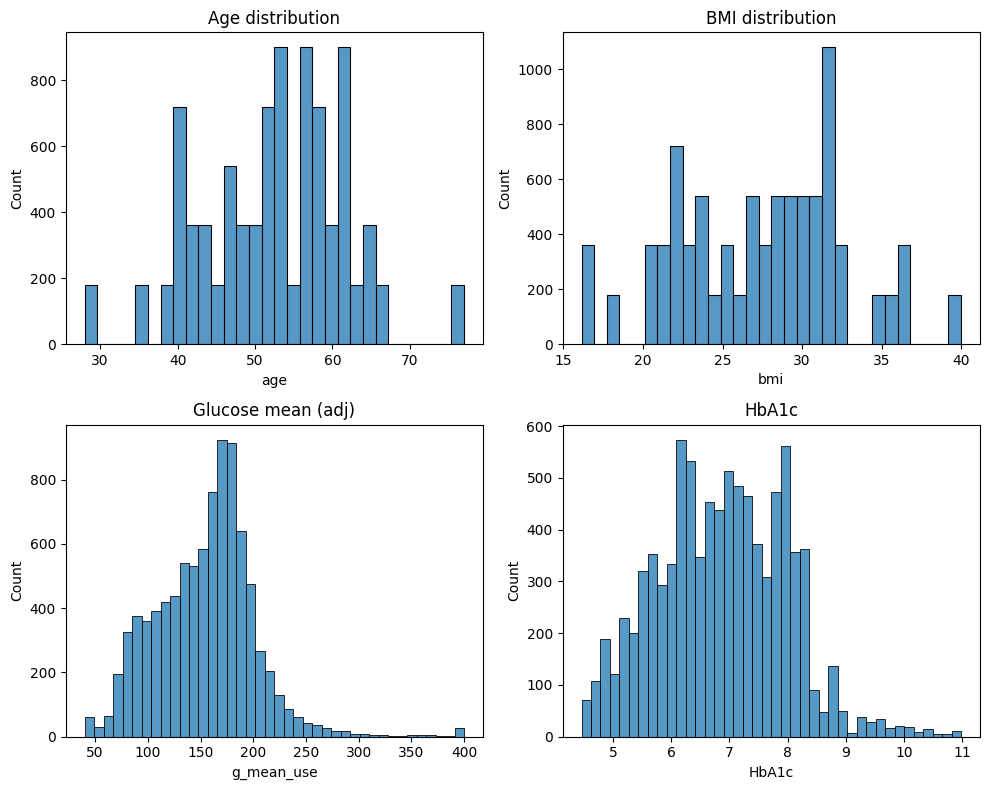

In [10]:
# 9) EDA: preview, prevalence, distributions
import seaborn as sns
import matplotlib.pyplot as plt

print('Shape:', final_df.shape)
print('Date range:', final_df['date'].min(), '->', final_df['date'].max())
print('Patients:', final_df['patient_id'].nunique())

display(final_df.head())

static_cols = ['has_CVD','has_CKD','has_chronic_allergy','alcohol_user','smoker']
print('\nStatic prevalence:')
print(final_df.groupby('patient_id')[static_cols].first().mean().round(3))

print('\nSex distribution:')
print(final_df.groupby('patient_id')['sex'].first().value_counts(normalize=True).round(3))

fig, axes = plt.subplots(2, 2, figsize=(10,8))
sns.histplot(final_df['age'].dropna(), bins=30, ax=axes[0,0])
axes[0,0].set_title('Age distribution')
sns.histplot(final_df['bmi'].dropna(), bins=30, ax=axes[0,1])
axes[0,1].set_title('BMI distribution')
sns.histplot(final_df['g_mean_use'].dropna(), bins=40, ax=axes[1,0])
axes[1,0].set_title('Glucose mean (adj)')
sns.histplot(final_df['HbA1c'].dropna(), bins=40, ax=axes[1,1])
axes[1,1].set_title('HbA1c')
plt.tight_layout(); plt.show()


In [11]:
# 10) NA and type checks

na_summary = final_df.isna().sum().sort_values(ascending=False)
print('Total NA (top 20):')
print(na_summary.head(20))

no_na_expected = [
    'patient_id','date','age','height_cm','weight_kg','bmi','has_CVD','has_CKD',
    'has_chronic_allergy','alcohol_user','smoker','g_mean_use','g_std_use','insulin_dose',
    'insulin_adherence','sleep_quality','exercise_minutes','meal_variability','stress_index',
    'illness_flag','missed_insulin','allergy_flare_day','alcohol_day','smoking_day',
    'stress_high_day','alcohol_rebound_day','g_mean_7d_mean','g_mean_14d_std','g_mean_14d_mean',
    'g_mean_30d_mean','hypo_past7d','hyper_past7d'
]

violations_na = [c for c in no_na_expected if final_df[c].isna().any()]
print('Unexpected NA columns:', violations_na)

expected_bins = ['illness_flag','missed_insulin','allergy_flare_day','alcohol_day','smoking_day','stress_high_day','alcohol_rebound_day','has_CVD','has_CKD','has_chronic_allergy','alcohol_user','smoker']
int_bin_bad = [c for c in expected_bins if not np.array_equal(final_df[c].dropna().astype(int), final_df[c].dropna())]
print('Binary not 0/1 integers:', int_bin_bad)


Total NA (top 20):
patient_id             0
g_mean_14d_std         0
allergy_flare_day      0
alcohol_day            0
smoking_day            0
stress_high_day        0
alcohol_rebound_day    0
g_mean_lag1            0
g_mean_7d_mean         0
insulin_dose_lag1      0
illness_flag           0
insulin_dose_lag2      0
insulin_dose_lag3      0
g_mean_14d_mean        0
g_mean_30d_mean        0
hypo_past7d            0
hyper_past7d           0
eAG                    0
missed_insulin         0
stress_index           0
dtype: int64
Unexpected NA columns: []
Binary not 0/1 integers: []


In [12]:
# 11) Continuity and duplicates

dupes = final_df.duplicated(subset=['patient_id','date']).sum()
print('Duplicate (patient_id,date) rows:', dupes)

continuity_issues = []
for pid, g in final_df.groupby('patient_id'):
    dt = pd.to_datetime(g['date']).sort_values().reset_index(drop=True)
    gaps = (dt.diff().dt.days.fillna(1) != 1).sum() - 1
    if gaps > 0:
        continuity_issues.append({'patient_id': pid, 'gaps': int(gaps)})

print('Patients with gaps:', len(continuity_issues))
if continuity_issues:
    display(pd.DataFrame(continuity_issues).head())


Duplicate (patient_id,date) rows: 0
Patients with gaps: 0


In [13]:
# 12) Sanity checks and quality report

checks = []

def add_check(name, ok, detail=None):
    checks.append({'check': name, 'status': 'PASS' if ok else 'FAIL', 'detail': detail})

add_check('age_range', final_df['age'].between(18, 100).all())
add_check('bmi_range', final_df['bmi'].between(10, 80).all())
add_check('glucose_mean_range', final_df['g_mean_use'].between(40, 500).all())
add_check('glucose_std_range', final_df['g_std_use'].between(0, 120).all())
# HbA1c: evaluate only after sufficient history (>= day 60 per patient), allow up to 18
_df = final_df.sort_values(['patient_id','date']).copy()
_df['day_idx'] = _df.groupby('patient_id').cumcount()
valid_hba1c = _df.loc[_df['day_idx'] >= 60, 'HbA1c'].dropna()
add_check('HbA1c_range', valid_hba1c.between(3, 18).all())

add_check('alcohol_rebound_requires_prev_alcohol',
          ((final_df['alcohol_rebound_day']==1) <= (final_df['alcohol_day'].shift(1)==1)).all())

# Allergy flare should be higher among chronic allergy patients (cohort-level)
_by_pid = final_df.groupby('patient_id').agg(
    has_chronic_allergy=('has_chronic_allergy','first'),
    flare_rate=('allergy_flare_day','mean')
)
_chronic_mean = _by_pid.loc[_by_pid['has_chronic_allergy']==1, 'flare_rate'].mean()
_non_mean = _by_pid.loc[_by_pid['has_chronic_allergy']==0, 'flare_rate'].mean()
add_check('allergy_flare_more_likely_if_chronic', _chronic_mean > _non_mean,
          f'chronic_mean={_chronic_mean:.3f} non_mean={_non_mean:.3f}')

# Sex sanity: male mean glucose higher than female (cohort-level)
_by_sex = final_df.groupby('patient_id').agg(sex=('sex','first'), g_mean=('g_mean_use','mean'))
_male = _by_sex.loc[_by_sex['sex']=='M','g_mean'].mean()
_female = _by_sex.loc[_by_sex['sex']=='F','g_mean'].mean()
add_check('sex_male_gt_female_mean_glucose', _male > _female, f'male={_male:.1f} female={_female:.1f}')

quality_report = pd.DataFrame(checks)
print('Quality checks:')
print(quality_report)

# Save JSON/CSV artifacts
from pathlib import Path
import json
report_dir = Path('../test_payloads')
report_dir.mkdir(parents=True, exist_ok=True)
report_path = report_dir / 'sim_augmented_quality_report.json'
issues_path = report_dir / 'sim_augmented_quality_issues.csv'

delta_targets = {
    'has_CVD': PREV.has_CVD,
    'has_CKD': PREV.has_CKD,
    'has_chronic_allergy': PREV.has_chronic_allergy,
    'alcohol_user': PREV.alcohol_user,
    'smoker': PREV.smoker,
}
by_patient = final_df.groupby('patient_id').first()
observed = by_patient[list(delta_targets.keys())].mean()
balance_df = pd.DataFrame({'target': delta_targets, 'observed': observed}).assign(delta=lambda d: d['observed'] - d['target'])

report = {
    'n_rows': int(len(final_df)),
    'n_patients': int(final_df['patient_id'].nunique()),
    'date_min': str(final_df['date'].min()),
    'date_max': str(final_df['date'].max()),
    'na_top': na_summary.head(20).to_dict(),
    'prevalence': balance_df.round(3).to_dict(orient='index'),
    'checks': quality_report.to_dict(orient='records'),
}

with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)

fails = quality_report.query("status == 'FAIL'")
if not fails.empty:
    fails.to_csv(issues_path, index=False)

print('Saved report to', report_path)
if not fails.empty:
    print('Saved issues to', issues_path)


Quality checks:
                                   check status  \
0                              age_range   PASS   
1                              bmi_range   PASS   
2                     glucose_mean_range   PASS   
3                      glucose_std_range   PASS   
4                            HbA1c_range   PASS   
5  alcohol_rebound_requires_prev_alcohol   PASS   
6   allergy_flare_more_likely_if_chronic   PASS   
7        sex_male_gt_female_mean_glucose   PASS   

                              detail  
0                               None  
1                               None  
2                               None  
3                               None  
4                               None  
5                               None  
6  chronic_mean=0.078 non_mean=0.038  
7            male=157.5 female=151.9  
Saved report to ../test_payloads/sim_augmented_quality_report.json
